# step 1: Import Necessary Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# step 2: Load the Dataset


In [29]:
df = pd.read_csv("Kuala_Lumpur_House_Prices.csv")

# Display first few rows to understand the structure
df.head()

,Location,Size,Bedrooms,Bathrooms,Age,Amenities,Price
0,Bukit Bintang,4705,1,3,25,Playground,3386218
1,Cheras,2187,5,3,47,Garden,3346038
2,Mont Kiara,2572,2,2,4,Swimming Pool,2857278
3,Bangsar,4203,3,3,0,NaN,2302637
4,Bukit Bintang,4865,3,1,34,NaN,4510240


# step 3: Explore the Data

In [33]:
# Check for missing values
df.isnull().sum()

# Summary statistics
df.describe()

# Count the number of unique locations
df['Location'].value_counts()

# Check data types
df.dtypes

Location     object
Size          int64
Bedrooms      int64
Bathrooms     int64
Age           int64
Amenities    object
Price         int64
dtype: object

# step 4: Data Preprocessing

In [35]:
# Convert Categorical Variables (Amenities and Location) into Numeric Format
df = pd.get_dummies(df, columns=['Location', 'Amenities'], drop_first=True)

# Display the transformed dataset
df.head()

,Size,Bedrooms,Bathrooms,Age,Price,Location_Bukit Bintang,Location_Cheras,Location_Damansara,Location_KLCC,Location_Mont Kiara,Location_Setapak,Location_Sri Hartamas,Amenities_Garden,Amenities_Gym,Amenities_Playground,Amenities_Security,Amenities_Swimming Pool
0,4705,1,3,25,3386218,True,False,False,False,False,False,False,False,False,True,False,False
1,2187,5,3,47,3346038,False,True,False,False,False,False,False,True,False,False,False,False
2,2572,2,2,4,2857278,False,False,False,False,True,False,False,False,False,False,False,True
3,4203,3,3,0,2302637,False,False,False,False,False,False,False,False,False,False,False,False
4,4865,3,1,34,4510240,True,False,False,False,False,False,False,False,False,False,False,False


# step 5: Spilt the Data into Training and Testing Sets

In [37]:
# Define independent variables (features) and dependent variable (target)
X = df.drop(columns=['Price']) # Features
y = df['Price'] # Target variable

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display dataset shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 16), (20, 16), (80,), (20,))

# step 6: Train a Linear Regression Model

In [39]:
# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Check model coefficients
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

                           Coefficient
Size                        106.360541
Bedrooms                 187049.912967
Bathrooms                 13051.977759
Age                       11088.636052
Location_Bukit Bintang   458150.564096
Location_Cheras         -568473.566849
Location_Damansara        95980.895523
Location_KLCC           -448730.856762
Location_Mont Kiara     -207418.306211
Location_Setapak        -852414.653444
Location_Sri Hartamas    117667.748705
Amenities_Garden         600595.608793
Amenities_Gym           -488005.071771
Amenities_Playground     -85010.827524
Amenities_Security       769920.214864
Amenities_Swimming Pool  533175.903030


# step 7: Make Predictions

In [41]:
# Predict on test data
y_pred = model.predict(X_test)

# Compare actual vs predicted
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head())

     Actual     Predicted
83  3256085  2.847743e+06
53  2729530  2.580622e+06
70  2077815  2.593729e+06
45  2788190  3.014050e+06
44   321544  1.189469e+06


In [ ]:
# step 8: Evaluate Model Performance

In [43]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-Squared: {r2}")

Mean Absolute Error: 954119.473803667
Mean Squared Error: 1388949554829.2075
Root Mean Squared Error: 1178537.0400751974
R-Squared: 0.01842518963301576


In [ ]:
# step 9: Visualizing Predictions

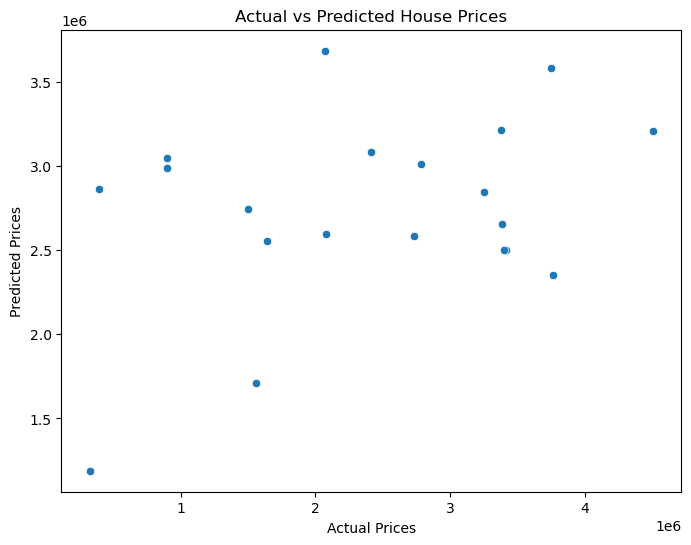

In [45]:
# Plot actual vs predicted prices
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
# step 10: Save the Model

In [47]:
import joblib

# Save trained model
joblib.dump(model, 'house_price_model.pkl')

# Load model later if needed
# Loaded_model = joblib.load('house_price_model.pkl')

['house_price_model.pkl']

In [ ]:
# step 11: User Input for House Price Prediction

In [ ]:
# function to take user input and predict house price
def predict_house_price(): 
    print("Enter details of the house:") 
    size = float(input("Enter house size in square feet: "))
    bedroom = int(input("Enter number of bedrooms: "))
    bathroom = int(input("Enter number of bathrooms: "))
    age = int(input("Enter property age in years: "))

    # List of possible locations and amenities from dataset
    locations = ['Bukit Bintang', 'Cheras', 'Mont Kiara', 'Bangsar', 'Damansara', 'Sri Petaling', 'Setapak', 'Sri Hartamas']
    amenities = ['Swimming Pool', 'Garden', 'Gym', 'Playground', 'Security']

    location = input(f"Enter house location from {locations}: ")
    amenity = input(f"Enter house amenity from {amenities}: ")

    # Create input dataframe
    input_data = pd.DataFrame([[size, bedroom, bathroom, age]], columns=['Size', 'Bedrooms', 'Bathrooms', 'Age'])

    # Add location and amenities columns (one-hot encoding as in training data)
    for loc in locations:
        input_data[f'Location_{loc}'] = 1 if loc == location else 0

    for am in amenities:
        input_data[f'Amenities_{am}'] = 1 if am == amenity else 0

    # Load trained model
    model = joblib.load('house_price_model.pkl')

    # Predict house price
    predicted_price = model.predict(input_data)[0]
    print(f"Predicted House Price: RM {predicted_price:.2f}")

# Call function to predict house price
predict_house_price()

Enter details of the house:
